In [1]:
# %pip install -q mplfinance==0.12.10b0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import mplfinance as mpf

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

TZ = "UTC"  # change if needed

### Load data from GCS

In [3]:
%%time

# GCS_URI = "gs://msads-mba-capstone-team-3/Data/bitcoin_btcusd.csv"
GCS_URI = "gs://msads-mba-capstone-team-3/Data/bitcoin_btcusd.parquet"

# df_raw = pd.read_csv(
#     GCS_URI,
#     sep=";",
#     skiprows=1,
#     engine="python",
#     encoding="utf-16",
# )

df_raw = pd.read_parquet(
    GCS_URI,
)


print(f"Loaded records: {df_raw.shape[0]}, columns: {df_raw.shape[1]}")
display(df_raw.head(5))

Loaded records: 3220762, columns: 8


,Date,Open,High,Low,Close,Tick Volume,Volume,Spread
0,2019.07.09 14:00,12561.65,12564.65,12560.65,12560.65,9,0,0
1,2019.07.09 14:01,12560.65,12560.65,12539.68,12552.66,43,0,0
2,2019.07.09 14:02,12552.66,12556.66,12545.67,12548.67,26,0,0
3,2019.07.09 14:03,12548.67,12548.67,12540.67,12544.67,9,0,0
4,2019.07.09 14:04,12544.67,12544.67,12544.67,12544.67,1,0,0


CPU times: user 1.18 s, sys: 504 ms, total: 1.68 s
Wall time: 3.13 s


### Basic cleaning & typing

In [4]:
COL_MAP = {
    "Date": "timestamp",
    "Open": "open",
    "High": "high",
    "Low": "low",
    "Close": "close",
    "Tick Volume": "tick_volume",
    "Volume": "volume",
    "Spread": "spread",
}
df = df_raw.rename(columns=COL_MAP).copy()

# Parse timestamp like "2019.07.09 14:00"
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%Y.%m.%d %H:%M", errors="coerce", utc=True)
# If you want a local tz, convert here:
df["timestamp"] = df["timestamp"].dt.tz_convert(TZ)

# Convert numerics
for c in ["open","high","low","close","tick_volume","volume","spread"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Drop fully-null timestamp rows (if any)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

# Make a seconds/minutes-granular index
df = df.set_index("timestamp")

print("Post-clean shape:", df.shape)
df.info()

Post-clean shape: (3220762, 7)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3220762 entries, 2019-07-09 14:00:00+00:00 to 2025-09-15 10:10:00+00:00
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   open         float64
 1   high         float64
 2   low          float64
 3   close        float64
 4   tick_volume  int64  
 5   volume       int64  
 6   spread       int64  
dtypes: float64(4), int64(3)
memory usage: 196.6 MB


### Quick sanity checks

In [5]:
summary = {
    "time_min": df.index.min(),
    "time_max": df.index.max(),
    "rows": len(df),
    "columns": list(df.columns),
    "null_counts": df.isna().sum().to_dict(),
    "duplicate_timestamp_rows": int(df.index.duplicated().sum()),
}
summary

{'time_min': Timestamp('2019-07-09 14:00:00+0000', tz='UTC'),
 'time_max': Timestamp('2025-09-15 10:10:00+0000', tz='UTC'),
 'rows': 3220762,
 'columns': ['open',
  'high',
  'low',
  'close',
  'tick_volume',
  'volume',
  'spread'],
 'null_counts': {'open': 0,
  'high': 0,
  'low': 0,
  'close': 0,
  'tick_volume': 0,
  'volume': 0,
  'spread': 0},
 'duplicate_timestamp_rows': 0}

### Per-minute completeness analysis

In [6]:
expected_index = pd.date_range(df.index.min(), df.index.max(), freq="min", tz=df.index.tz)
actual_index = df.index

missing_index = expected_index.difference(actual_index)
extra_index = actual_index.difference(expected_index)  # should normally be empty if data is within [min,max]

completeness = 100 * (1 - len(missing_index)/len(expected_index)) if len(expected_index) else np.nan

print(f"Expected per-minute rows: {len(expected_index):,}")
print(f"Actual rows:             {len(actual_index):,}")
print(f"Missing minutes:         {len(missing_index):,}")
print(f"Extra (off-grid) times:  {len(extra_index):,}")
print(f"Completeness:            {completeness:.4f}%")


Expected per-minute rows: 3,254,171
Actual rows:             3,220,762
Missing minutes:         33,409
Extra (off-grid) times:  0
Completeness:            98.9733%


### Gap detection: contiguous missing ranges

In [7]:
%%time

# Turn missing minute timestamps into start/end ranges
def missing_ranges(ts_index):
    if len(ts_index) == 0:
        return pd.DataFrame(columns=["gap_start","gap_end","minutes","hours","days"])
    
    s = pd.Series(ts_index)
    # Find breaks (where difference is not 1 minute)
    breaks = s.diff() != pd.Timedelta(minutes=1)
    groups = breaks.cumsum()
    grp = s.groupby(groups)
    
    out = pd.DataFrame({
        "gap_start": grp.first(),
        "gap_end": grp.last()
    })
    out["minutes"] = (out["gap_end"] - out["gap_start"]).dt.total_seconds().div(60) + 1
    out["hours"]   = out["minutes"] / 60
    out["days"]    = out["minutes"] / 1440  # 24*60
    out = out.reset_index(drop=True)
    return out

gap_df = missing_ranges(missing_index)
display(gap_df.nlargest(10, "minutes"))

,gap_start,gap_end,minutes,hours,days
718,2020-06-05 19:03:00+00:00,2020-06-07 14:46:00+00:00,2624.0,43.733333,1.822222
1679,2024-07-05 19:33:00+00:00,2024-07-07 04:55:00+00:00,2003.0,33.383333,1.390972
1680,2024-07-12 19:32:00+00:00,2024-07-14 00:39:00+00:00,1748.0,29.133333,1.213889
1652,2024-04-12 19:32:00+00:00,2024-04-13 05:05:00+00:00,574.0,9.566667,0.398611
1635,2024-02-23 19:32:00+00:00,2024-02-24 05:02:00+00:00,571.0,9.516667,0.396528
717,2020-05-29 19:03:00+00:00,2020-05-30 04:28:00+00:00,566.0,9.433333,0.393056
965,2021-06-30 02:20:00+00:00,2021-06-30 11:19:00+00:00,540.0,9.000000,0.375000
1929,2024-10-04 19:32:00+00:00,2024-10-05 02:10:00+00:00,399.0,6.650000,0.277083
1068,2022-02-04 23:25:00+00:00,2022-02-05 05:48:00+00:00,384.0,6.400000,0.266667
780,2020-09-20 00:06:00+00:00,2020-09-20 05:54:00+00:00,349.0,5.816667,0.242361


CPU times: user 17.5 ms, sys: 1.06 ms, total: 18.5 ms
Wall time: 62.6 ms


### Duplicate timestamps (if any)

In [8]:
dups = df.index[df.index.duplicated()]
dup_count = len(dups)
print(f"Duplicate minute timestamps: {dup_count}")
if dup_count:
    display(pd.DataFrame(dups, columns=["duplicate_timestamp"]).head(20))

Duplicate minute timestamps: 0


### Basic descriptive stats

In [9]:
desc = df[["open","high","low","close","tick_volume","volume","spread"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
open,3220762.0,41502.666838,29771.823633,4020.71,6719.6488,8083.08,17835.350,34280.805,59523.8125,104836.0995,117622.9478,124472.34
high,3220762.0,41519.918552,29781.800588,4042.43,6722.6861,8085.28,17844.340,34302.220,59551.1075,104865.0995,117649.4907,124506.86
low,3220762.0,41485.289296,29761.924167,3995.09,6716.5549,8080.79,17827.360,34259.270,59498.1175,104808.4800,117599.4600,124316.56
close,3220762.0,41502.834568,29771.945592,3996.28,6719.7800,8083.28,17835.295,34280.510,59523.6100,104836.9980,117623.7739,124472.34
tick_volume,3220762.0,48.839314,59.594789,1.00,1.0000,1.00,11.000,29.000,63.0000,173.0000,295.0000,849.00
volume,3220762.0,0.000000,0.000000,0.00,0.0000,0.00,0.000,0.000,0.0000,0.0000,0.0000,0.00
spread,3220762.0,0.000000,0.000000,0.00,0.0000,0.00,0.000,0.000,0.0000,0.0000,0.0000,0.00


### Price trend visual

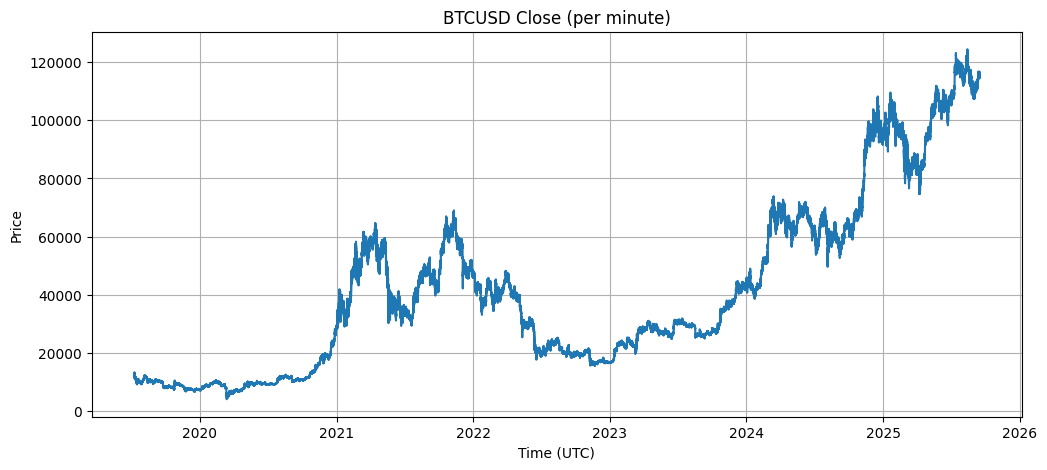

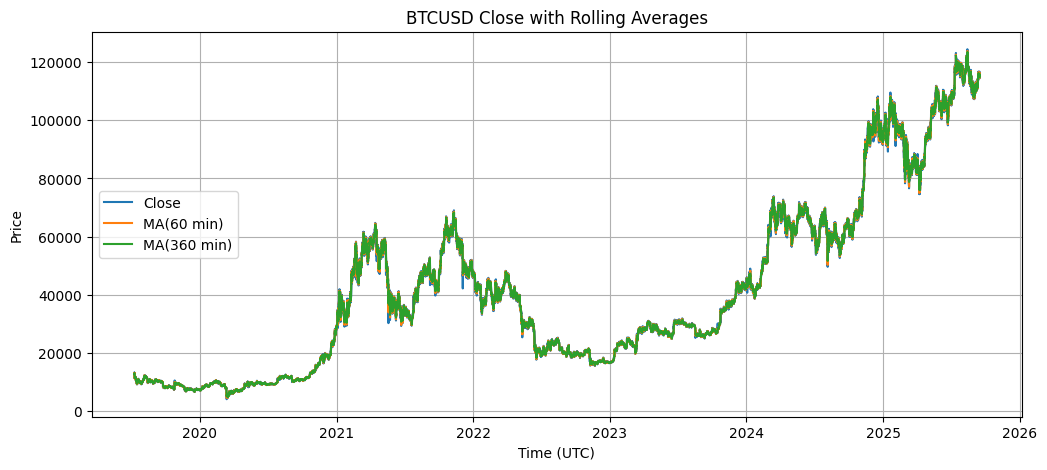

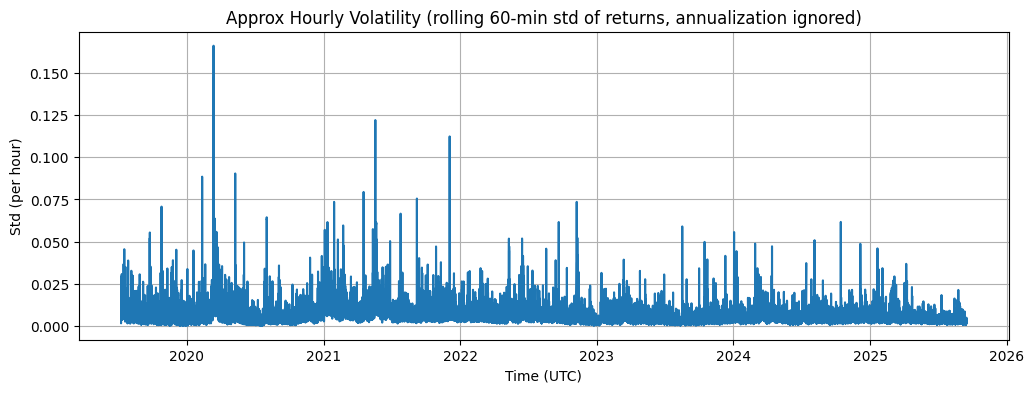

CPU times: user 1min 44s, sys: 2.46 s, total: 1min 47s
Wall time: 1min 47s


In [10]:
%%time

plt.figure(figsize=(12,5))
plt.plot(df.index, df["close"])
plt.title("BTCUSD Close (per minute)")
plt.xlabel(f"Time ({TZ})")
plt.ylabel("Price")
plt.grid(True)
plt.show()

# Rolling means / volatility
close = df["close"].astype(float)
roll_60 = close.rolling(60, min_periods=1).mean()
roll_360 = close.rolling(360, min_periods=1).mean()
ret = close.pct_change()
vol_60 = ret.rolling(60, min_periods=1).std() * np.sqrt(60)  # approx hourly vol

plt.figure(figsize=(12,5))
plt.plot(close.index, close, label="Close")
plt.plot(roll_60.index, roll_60, label="MA(60 min)")
plt.plot(roll_360.index, roll_360, label="MA(360 min)")
plt.title("BTCUSD Close with Rolling Averages")
plt.xlabel(f"Time ({TZ})"); plt.ylabel("Price")
plt.legend(loc="center left"); plt.grid(True); plt.show()

plt.figure(figsize=(12,4))
plt.plot(vol_60.index, vol_60)
plt.title("Approx Hourly Volatility (rolling 60-min std of returns, annualization ignored)")
plt.xlabel(f"Time ({TZ})"); plt.ylabel("Std (per hour)")
plt.grid(True); plt.show()

### Volume & spread visuals

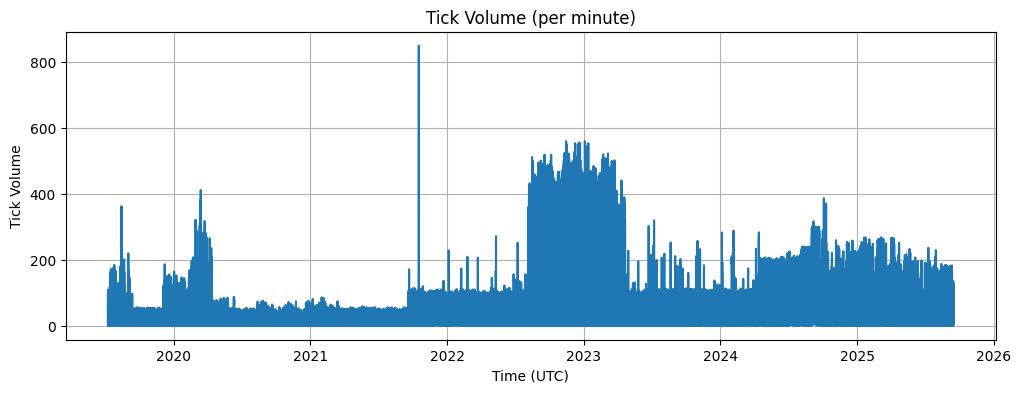

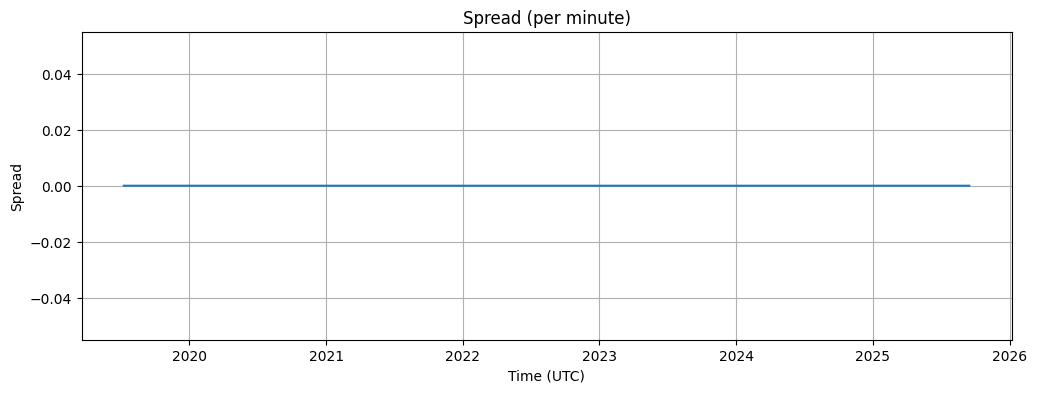

CPU times: user 42.4 s, sys: 1.02 s, total: 43.4 s
Wall time: 43.4 s


In [11]:
%%time

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(df.index, df["tick_volume"])
ax.set_title("Tick Volume (per minute)")
ax.set_xlabel(f"Time ({TZ})"); ax.set_ylabel("Tick Volume")
ax.grid(True)
plt.show()

if "spread" in df.columns:
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(df.index, df["spread"])
    ax.set_title("Spread (per minute)")
    ax.set_xlabel(f"Time ({TZ})"); ax.set_ylabel("Spread")
    ax.grid(True)
    plt.show()

### Resampled views (hourly & daily)

In [12]:
%%time

ohlc_cols = ["open","high","low","close"]

df_1h = df[ohlc_cols + ["tick_volume","volume","spread"]].resample("1h").agg({
    "open":"first", "high":"max", "low":"min", "close":"last",
    "tick_volume":"sum", "volume":"sum", "spread":"mean"
})

df_1d = df[ohlc_cols + ["tick_volume","volume","spread"]].resample("1d").agg({
    "open":"first", "high":"max", "low":"min", "close":"last",
    "tick_volume":"sum", "volume":"sum", "spread":"mean"
})

display(df_1h.head())
display(df_1d.head())

,open,high,low,close,tick_volume,volume,spread
timestamp,,,,,,,
2019-07-09 14:00:00+00:00,12561.65,12604.60,12492.73,12548.67,1090,0,0.0
2019-07-09 15:00:00+00:00,12548.67,12882.30,12525.69,12868.31,1453,0,0.0
2019-07-09 16:00:00+00:00,12868.31,12971.20,12840.34,12895.28,1260,0,0.0
2019-07-09 17:00:00+00:00,12895.28,13092.07,12895.28,13028.14,1790,0,0.0
2019-07-09 18:00:00+00:00,13028.14,13108.05,12860.32,12955.22,1559,0,0.0


,open,high,low,close,tick_volume,volume,spread
timestamp,,,,,,,
2019-07-09 00:00:00+00:00,12561.65,13108.05,12492.73,12936.24,10604,0,0.0
2019-07-10 00:00:00+00:00,12936.24,13158.99,11150.21,11424.90,38791,0,0.0
2019-07-11 00:00:00+00:00,11424.90,11777.51,10959.42,11586.73,39905,0,0.0
2019-07-12 00:00:00+00:00,11586.73,11885.40,11405.92,11516.80,18746,0,0.0
2019-07-13 00:00:00+00:00,11516.80,11583.73,10792.60,11012.36,23252,0,0.0


CPU times: user 457 ms, sys: 88 ms, total: 545 ms
Wall time: 604 ms


### Candlestick (daily) with mplfinance

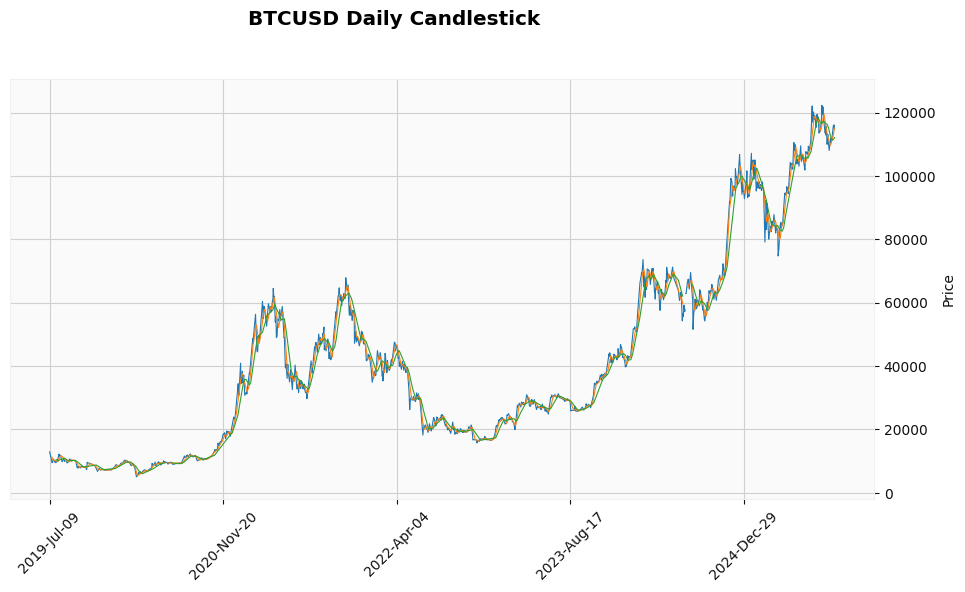

CPU times: user 163 ms, sys: 4.22 ms, total: 167 ms
Wall time: 217 ms


In [13]:
%%time

# Requires a DatetimeIndex named 'Date' and columns: Open,High,Low,Close[,Volume]
daily_for_mpf = df_1d.copy()
daily_for_mpf.index.name = "Date"
daily_for_mpf = daily_for_mpf.rename(columns=str.capitalize)

if not daily_for_mpf[["Open","High","Low","Close"]].isna().all().any():
    mpf.plot(
        daily_for_mpf,
        # type="candle",
        type="line",        
        style="yahoo",
        title="BTCUSD Daily Candlestick",
        ylabel="Price",
        volume=False,
        mav=(7,20),
        figsize=(12,6),
    )
else:
    print("Not enough complete daily OHLC for candlestick (check data range).")

### Returns analysis

In [14]:
%%time

r1 = df["close"].pct_change()
r5 = df["close"].pct_change(5)
r60 = df["close"].pct_change(60)

returns_summary = pd.DataFrame({
    "horizon": ["1 min","5 min","60 min"],
    "mean": [r1.mean(), r5.mean(), r60.mean()],
    "std": [r1.std(), r5.std(), r60.std()],
    "min": [r1.min(), r5.min(), r60.min()],
    "max": [r1.max(), r5.max(), r60.max()],
    "non_null_obs": [r1.notna().sum(), r5.notna().sum(), r60.notna().sum()],
})
returns_summary

CPU times: user 305 ms, sys: 12 ms, total: 317 ms
Wall time: 314 ms


,horizon,mean,std,min,max,non_null_obs
0,1 min,0.000001,0.000923,-0.053792,0.069021,3220761
1,5 min,0.000006,0.002071,-0.116997,0.139648,3220757
2,60 min,0.000065,0.006872,-0.226644,0.327312,3220702


### Completeness heatmap (minutes missing per day)

In [15]:
%%time

# Build a per-day count of missing minutes
missing_df = pd.DataFrame(index=missing_index)
if not missing_df.empty:
    missing_df["day"] = missing_df.index.tz_convert(TZ).date
    per_day_missing = missing_df.groupby("day").size()
    per_day_total = pd.Series(1440, index=pd.unique(df.index.date))  # 1440 minutes per day
    completeness_daily = (
        pd.DataFrame({"missing": per_day_missing})
        .fillna(0)
        .reindex(sorted(pd.unique(df.index.date)))
        .assign(total=1440)
        .assign(completeness=lambda x: 100*(1 - x["missing"]/x["total"]))
    )

    fig = px.bar(
        completeness_daily.reset_index().rename(columns={"index":"day"}),
        x="day", y="completeness",
        title="Daily Completeness (%)",
        labels={"day":"Day", "completeness":"% complete"},
    )
    fig.update_yaxes(range=[0,100])
    fig.show()
else:
    print("No missing minutes across the covered range — completeness is 100%.")

No missing minutes across the covered range — completeness is 100%.
CPU times: user 407 μs, sys: 0 ns, total: 407 μs
Wall time: 387 μs


### Final EDA summary report (printout)

In [16]:
def fmt_pct(x):
    return "NaN" if pd.isna(x) else f"{x:.4f}%"

report = {
    "Start": df.index.min(),
    "End": df.index.max(),
    "Observed rows": len(df),
    "Expected rows (per-minute)": len(pd.date_range(df.index.min(), df.index.max(), freq="min", tz=df.index.tz)),
    "Missing minutes": len(missing_index),
    "Completeness (%)": fmt_pct(100 * (1 - len(missing_index)/len(pd.date_range(df.index.min(), df.index.max(), freq='min', tz=df.index.tz)))),
    "Duplicate timestamps": int(df.index.duplicated().sum()),
    "Close mean": float(df["close"].mean()),
    "Close std": float(df["close"].std()),
    "Close min": float(df["close"].min()),
    "Close max": float(df["close"].max()),
}

print("=== BTCUSD Minute EDA Summary ===")
for k,v in report.items():
    print(f"{k:>24}: {v}")
print("\nTop 10 largest gaps by duration (minutes):")
if not gap_df.empty:
    display(gap_df.sort_values("minutes", ascending=False).head(10))
else:
    print("No gaps detected.")

=== BTCUSD Minute EDA Summary ===
                   Start: 2019-07-09 14:00:00+00:00
                     End: 2025-09-15 10:10:00+00:00
           Observed rows: 3220762
Expected rows (per-minute): 3254171
         Missing minutes: 33409
        Completeness (%): 98.9733%
    Duplicate timestamps: 0
              Close mean: 41502.83456775447
               Close std: 29771.94559189506
               Close min: 3996.28
               Close max: 124472.34

Top 10 largest gaps by duration (minutes):


,gap_start,gap_end,minutes,hours,days
718,2020-06-05 19:03:00+00:00,2020-06-07 14:46:00+00:00,2624.0,43.733333,1.822222
1679,2024-07-05 19:33:00+00:00,2024-07-07 04:55:00+00:00,2003.0,33.383333,1.390972
1680,2024-07-12 19:32:00+00:00,2024-07-14 00:39:00+00:00,1748.0,29.133333,1.213889
1652,2024-04-12 19:32:00+00:00,2024-04-13 05:05:00+00:00,574.0,9.566667,0.398611
1635,2024-02-23 19:32:00+00:00,2024-02-24 05:02:00+00:00,571.0,9.516667,0.396528
717,2020-05-29 19:03:00+00:00,2020-05-30 04:28:00+00:00,566.0,9.433333,0.393056
965,2021-06-30 02:20:00+00:00,2021-06-30 11:19:00+00:00,540.0,9.000000,0.375000
1929,2024-10-04 19:32:00+00:00,2024-10-05 02:10:00+00:00,399.0,6.650000,0.277083
1068,2022-02-04 23:25:00+00:00,2022-02-05 05:48:00+00:00,384.0,6.400000,0.266667
780,2020-09-20 00:06:00+00:00,2020-09-20 05:54:00+00:00,349.0,5.816667,0.242361


In [17]:
import datetime
import pytz

last_executed = datetime.datetime.now(pytz.timezone('US/Eastern')).strftime("%a, %d %B %Y %H:%M:%S")
print(f'Notebook Last Executed on: {last_executed}')

Notebook Last Executed on: Wed, 28 January 2026 17:31:04


In [18]:
# Save df for processing
df.to_parquet("df_min.parquet", index=True)

### Basic descriptive stats - 1hr

In [19]:
# Save 1h df for processing
# df_1h.to_parquet("df_1h.parquet", index=True)

In [20]:
desc = df_1h[["open","high","low","close","tick_volume","volume","spread"]].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T
display(desc)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
open,54012.0,41603.896111,29847.798434,4297.39,6724.7639,8086.880,17915.7700,34386.985,59663.1600,104947.8695,117645.9169,123893.84
high,54012.0,41770.281209,29941.619573,4639.08,6763.8709,8112.345,18020.6500,34555.860,59949.2200,105234.1675,117848.8105,124506.86
low,54012.0,41430.472671,29753.073918,3995.09,6682.9510,8057.165,17802.1475,34154.080,59406.8975,104649.9700,117385.6196,123381.08
close,54012.0,41605.927535,29849.207562,4288.26,6724.7639,8086.880,17917.7625,34386.395,59663.0775,104946.7250,117646.8112,123895.32
tick_volume,54237.0,2900.230617,3275.497783,0.00,91.0000,198.000,810.0000,1779.000,3722.0000,9822.4000,16775.4800,26594.00
volume,54237.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.00
spread,54012.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.00


Avg |hourly log return|: 0.004095629372700423
Median |hourly log return|: 0.0024647657501883913
Hourly vol (std log ret): 0.006866987702211602
Annualized vol (24/7): 0.6427148326407057


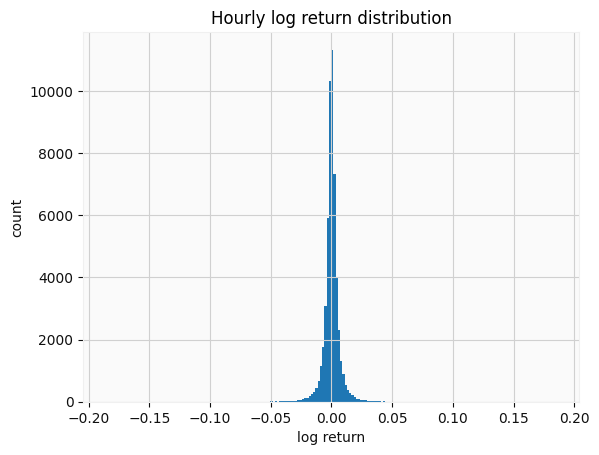

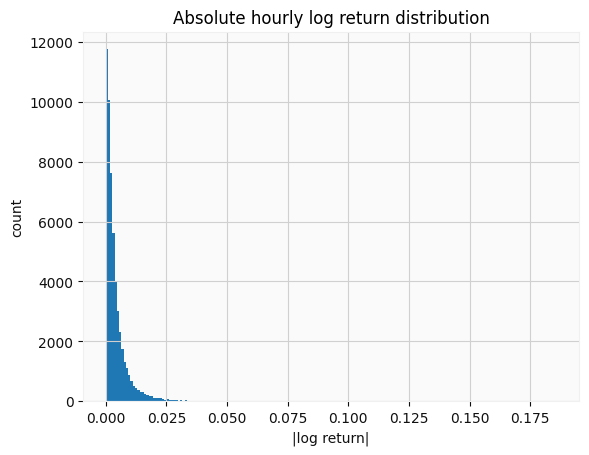

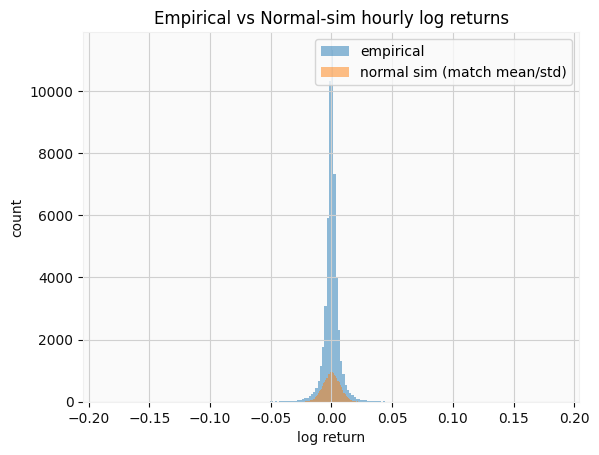


Return quantiles:
0.01   -0.020291
0.05   -0.009223
0.25   -0.002387
0.50    0.000059
0.75    0.002545
0.95    0.009368
0.99    0.019318
Name: close, dtype: float64

Abs-move quantiles:
0.01    0.000042
0.05    0.000205
0.25    0.001070
0.50    0.002465
0.75    0.005036
0.95    0.013428
0.99    0.025409
Name: close, dtype: float64

High-low range quantiles (log(high/low)):
0.01    0.001095
0.05    0.001975
0.25    0.004023
0.50    0.006420
0.75    0.010421
0.95    0.021985
0.99    0.038320
dtype: float64


In [21]:
# --- 1) Hourly returns from df_1h close ---
px = df_1h["close"].astype(float).dropna()

# log returns and simple returns
r_log = np.log(px).diff().dropna()
r_simple = px.pct_change().dropna()

# "movement" measures
abs_move = r_log.abs()                    # absolute log return per hour
hl_range = np.log(df_1h["high"]/df_1h["low"]).replace([np.inf, -np.inf], np.nan).dropna()  # intrahour range

# --- 2) Average hourly movement ---
avg_abs_move = abs_move.mean()
med_abs_move = abs_move.median()
hourly_vol = r_log.std()

print("Avg |hourly log return|:", avg_abs_move)
print("Median |hourly log return|:", med_abs_move)
print("Hourly vol (std log ret):", hourly_vol)

# Optional: annualize (24*365 hours in crypto; or use 252*6.5 for equities)
ann_vol = hourly_vol * np.sqrt(24*365)
print("Annualized vol (24/7):", ann_vol)

# --- 3) Observe distribution (histogram) ---
plt.figure()
plt.hist(r_log, bins=200)
plt.title("Hourly log return distribution")
plt.xlabel("log return")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(abs_move, bins=200)
plt.title("Absolute hourly log return distribution")
plt.xlabel("|log return|")
plt.ylabel("count")
plt.show()

# --- 4) Simple simulation: Normal with same mean/std as empirical log returns ---
np.random.seed(0)
n = len(r_log)
mu, sigma = r_log.mean(), r_log.std()
sim = np.random.normal(mu, sigma, size=n)

plt.figure()
plt.hist(r_log, bins=200, alpha=0.5, label="empirical")
plt.hist(sim,   bins=200, alpha=0.5, label="normal sim (match mean/std)")
plt.title("Empirical vs Normal-sim hourly log returns")
plt.xlabel("log return")
plt.ylabel("count")
plt.legend()
plt.show()

# --- 5) Optional: check tails via quantiles (movement + return) ---
q = [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
print("\nReturn quantiles:")
print(r_log.quantile(q))
print("\nAbs-move quantiles:")
print(abs_move.quantile(q))
print("\nHigh-low range quantiles (log(high/low)):")
print(hl_range.quantile(q))